# Tasca S11.01. Visualització de Dades amb Python i Power BI

**Descripció**  
Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

## Llibreries

In [1]:
import mysql.connector
from mysql.connector import Error

from dotenv import load_dotenv  
import os

load_dotenv()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.ticker as ticker
import datetime as dt
from datetime import datetime, date

## **Nivell 1**

### **1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.**

#### Connexió amb la base de dades s4_transactions

In [2]:
# Document amb environment (.env) on hi ha les dades del host, user i password
try:
    connection = mysql.connector.connect(host=os.getenv("DB_HOST"),
                                         database='s4_transactions',
                                         user=os.getenv('DB_USER'),
                                         password=os.getenv('DB_PASSWORD'))
    if connection.is_connected():
        cursor = connection.cursor(buffered=True)
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)

You're connected to database:  ('s4_transactions',)


#### Càrrega de la base de dades s4_transactions

In [3]:
cursor.execute("Show tables;")

tables = cursor.fetchall()

for x in tables:
    print(x)
    print(type(x))

('active_credit_cards',)
<class 'tuple'>
('all_users',)
<class 'tuple'>
('companies',)
<class 'tuple'>
('credit_cards',)
<class 'tuple'>
('products',)
<class 'tuple'>
('transaction_product',)
<class 'tuple'>
('transactions',)
<class 'tuple'>


###### Create a dictionary of dataframes

In [4]:
def select_table(table_name: str):
    query = f"SELECT * FROM {table_name}"
    cursor.execute(query)
    
    data = cursor.fetchall()
    columns = [col[0] for col in cursor.description]

    df = pd.DataFrame(data, columns=columns)
    return df

In [5]:
tables_df = {}

for x in tables:
    table_name = x[0]
    tables_df[table_name] = select_table(table_name)

# tables_df = {table_name: select_table(table_name) for (table_name,) in tables}

In [6]:
tables_df['companies'].head(5)

,company_id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings\r


#### Taules disponibles

In [7]:
type(tables_df)

dict

In [8]:
for x, y in tables_df.items():
    print(x)
    display(y.head(5))
    print("-----")

active_credit_cards


,card_id,state
0,CcS-4857,active
1,CcS-4858,active
2,CcS-4859,active
3,CcS-4860,active
4,CcS-4861,active


-----
all_users


,id,name,surname,phone,email,birth_date,country,city,postal_code,address,region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,america
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,"Apr 30, 1984",United States,San Jose,95101,P.O. Box 773,america
2,100,Melodie,Mclean,1-677-221-7152,risus.varius@google.ca,"Sep 15, 1989",United States,San Jose,95101,Ap #644-8492 Sagittis St.,america
3,1000,Amkjrv,Qbulrxbp,+48-258-9936,amkjrv.qbulrxbp@example.com,"May 17, 1970",Germany,Stuttgart,70173,215 Qbulrxbp St,europe
4,1001,Nfvrlb,Oydaiwbg,+94-121-2522,nfvrlb.oydaiwbg@example.com,"Mar 4, 1994",Germany,Cologne,50667,121 Oydaiwbg St,europe


-----
companies


...

-----
transaction_product


,transaction_id,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87
4,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66


-----
transactions


,id,card_id,business_id,transaction_date,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.19992926158272,1.4355402821327607
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.59720554463741,12.22175994259365
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.757295899964348,-95.37963676492454
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.6,0,72,2115,53.54888376797025,-113.50305274646564
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.20836951654172,5.690806474241335


-----


Query modelo para usar.

query = """
SELECT u.country, o.amount
FROM orders o
JOIN users u ON o.user_id = u.id
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = [col[0] for col in cursor.description]

df = pd.DataFrame(data, columns=columns)

###### Una altra opció: crear un diccionari de tuples

In [9]:
def select_table(table_name: str):
    query = f"SELECT * FROM {table_name}"
    cursor.execute(query)
    
    data = cursor.fetchall()
    columns = [col[0] for col in cursor.description]
    
    return {
        "columns": columns,
        "data": data
    }

In [10]:
tables_data = {}

for x in tables:
    table_name = x[0]
    tables_data[table_name] = select_table(table_name)

In [11]:
tables_data['companies']

{'columns': ['company_id',
  'company_name',
  'phone',
  'email',
  'country',
  'website'],
 'data': [('b-2222',
   'Ac Fermentum Incorporated',
   '06 85 56 52 33',
   'donec.porttitor.tellus@yahoo.net',
   'Germany',
   'https://instagram.com/site\r'),
  ('b-2226',
   'Magna A Neque Industries',
   '04 14 44 64 62',
   'risus.donec.nibh@icloud.org',
   'Australia',
   'https://whatsapp.com/group/9\r'),
  ('b-2230',
   'Fusce Corp.',
   '08 14 97 58 85',
   'risus@protonmail.edu',
   'United States',
   'https://pinterest.com/sub/cars\r'),
  ('b-2234',
   'Convallis In Incorporated',
   '06 66 57 29 50',
   'mauris.ut@aol.couk',
   'Germany',
   'https://cnn.com/user/110\r'),
  ('b-2238',
   'Ante Iaculis Nec Foundation',
   '08 23 04 99 53',
   'sed.dictum.proin@outlook.ca',
   'New Zealand',
   'https://netflix.com/settings\r'),
  ('b-2242',
   'Donec Ltd',
   '01 25 51 37 37',
   'at.iaculis@hotmail.couk',
   'Norway',
   'https://nytimes.com/user/110\r'),
  ('b-2246',
   'Sed Nu

### **2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.**

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

Definició de tema de colors de gràfics:

In [12]:
sns.set_style("dark")
sns.set_palette("pastel")


#### Una variable numèrica

Preparació de dades

In [13]:
df_products = tables_df['products'].copy()
df_products.head(5)

,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,$161.11,#7c7c7c,1,WH-4
1,2,Tarly Stark,$9.24,#919191,2,WH-3
2,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2
3,4,warden south duel,$71.89,#111111,3,WH-1
4,5,skywalker ewok,$171.22,#dbdbdb,3.2,WH-0


In [14]:
df_products['price'].describe().T

count         100
unique        100
top       $161.11
freq            1
Name: price, dtype: object

In [15]:
df_products['price'] = (
    df_products['price']
    .str.replace('$', '', regex=False)
    .astype(float)
)
df_products['price'].describe().T


count    100.000000
mean     102.007200
std       59.795203
min        2.120000
25%       53.235000
50%       96.580000
75%      158.995000
max      196.650000
Name: price, dtype: float64

Gràfic

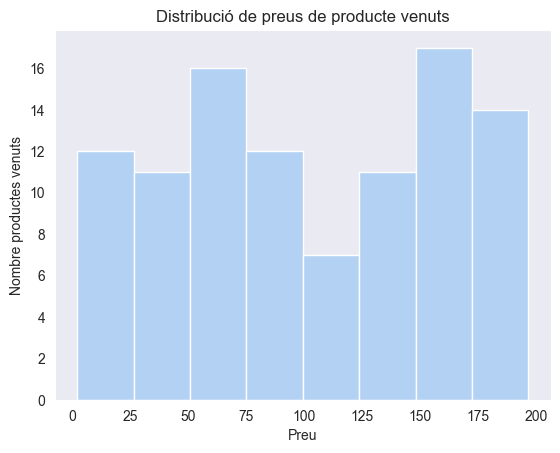

In [16]:
fig = sns.histplot(data=df_products, x='price').set(title='Distribució de preus de producte venuts',xlabel='Preu', ylabel='Nombre productes venuts')

**Interpretació dels resultats**

Pel que fa a la distribució dels preus dels productes venuts, veiem que hi ha alguns rangs de preu en els que es venen més productes (e.g. 50-75, 150-175$), mentre que per al rang de 100 a 125$ és la franja on s'han venut menys productes.

Seria bo mirar quin marge de benefici té cadascun dels productes per veure si es poden ajustar més aquests preus per tal de maximitzar els guanys.

#### Dues variables numèriques.

Preparació dades

In [17]:
query = """
SELECT p.id AS product, COUNT(p.id) as units_sold, p.price
FROM products p
JOIN transaction_product tp ON tp.product_id = p.id
JOIN transactions t ON tp.transaction_id = t.id
WHERE declined = 0
GROUP BY p.id
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = [col[0] for col in cursor.description]

df_count_products_price = pd.DataFrame(data, columns=columns)

In [18]:
df_count_products_price['price'] = (
    df_count_products_price['price']
    .str.replace('$', '', regex=False)
    .astype(float))
df_count_products_price

,product,units_sold,price
0,16,2602,180.91
1,26,2532,53.01
2,97,2520,65.25
3,87,2591,96.26
4,66,2590,2.12
...,...,...,...
95,59,2479,114.77
96,60,2502,68.38
97,77,2453,150.50
98,86,2514,189.21


Gràfic

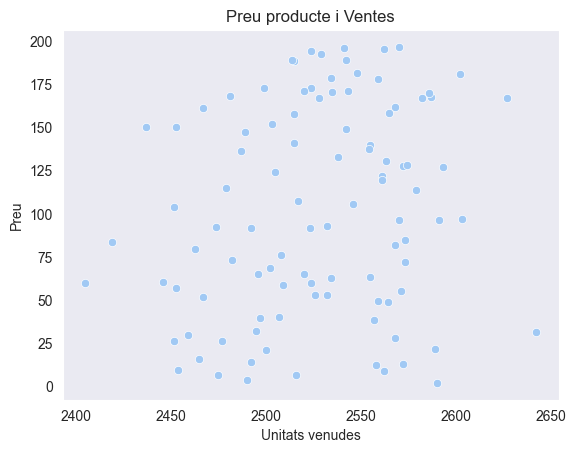

In [19]:
fig = sns.scatterplot(data=df_count_products_price, x='units_sold', y= 'price').set(title='Preu producte i Ventes',xlabel='Unitats venudes', ylabel='Preu')

**Interpretació dels resultats**

No sembla que existeixi una relació directa entre el nombre d'unitats venudes i el preu dels productes, així que hi ha altres variables a part del preu que influeixen en la quantitat de ventes d'un producte.

#### Una variable categòrica.

Preparació de dades

In [20]:
df_users = tables_df['all_users'].copy()
df_users.head(5)

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,america
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,"Apr 30, 1984",United States,San Jose,95101,P.O. Box 773,america
2,100,Melodie,Mclean,1-677-221-7152,risus.varius@google.ca,"Sep 15, 1989",United States,San Jose,95101,Ap #644-8492 Sagittis St.,america
3,1000,Amkjrv,Qbulrxbp,+48-258-9936,amkjrv.qbulrxbp@example.com,"May 17, 1970",Germany,Stuttgart,70173,215 Qbulrxbp St,europe
4,1001,Nfvrlb,Oydaiwbg,+94-121-2522,nfvrlb.oydaiwbg@example.com,"Mar 4, 1994",Germany,Cologne,50667,121 Oydaiwbg St,europe


Gràfic

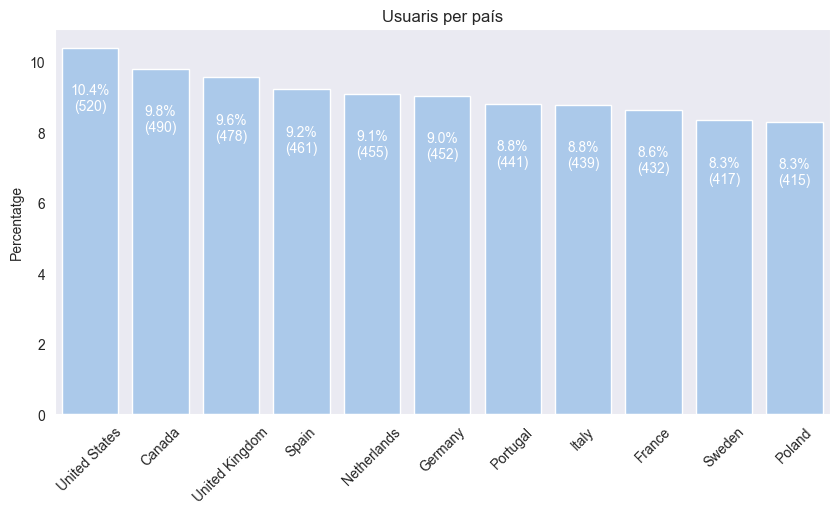

In [21]:
plt.figure(figsize=(10,5))

# ordre
order = df_users['country'].value_counts().index

# countplot en percentatge
ax = sns.countplot(
    x='country',
    data=df_users,
    order=order,
    stat='percent'
)

plt.xticks(rotation=45)

# counts reals
counts = df_users['country'].value_counts()

# anotacions
for i, p in enumerate(ax.patches):
    country = order[i]
    count = counts[country]
    percent = p.get_height()

    ax.annotate(
        f'{percent:.1f}%\n({count})',
        (p.get_x() + p.get_width() / 2., p.get_height() - 1),  # ↓ baixa una mica
        ha='center',
        va='top',
        color='white'  # opcional: millor contrast
    )

plt.title('Usuaris per país')
plt.xlabel('')
plt.ylabel('Percentatge')
plt.show()

**Interpretació dels resultats**

Tot i que la diferència d'usuaris entre el pais que en té més amb el que en té menys és de 105 usuaris, això només representa una diferència de 2,1%. A més, no hi ha cap pais que destaqui per sobre dels altres pel que fa al nombre d'usuaris.

Altres maneres de fer-ho:

df_users['country'].value_counts().plot.bar()

Matplotlib
counts = df_users['country'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Users per country')

plt.xticks(rotation=45)
plt.show()

#### Una variable categòrica i una numèrica.

Preparació de dades

In [22]:
query = """
SELECT t.id, t.amount, u.country
FROM transactions t
JOIN all_users u ON u.id = t.user_id
WHERE declined = 0
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = [col[0] for col in cursor.description]

df_transaction_country = pd.DataFrame(data, columns=columns)

In [23]:
df_transaction_country

,id,amount,country
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,395.43,France
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,155.63,Italy
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,326.01,United States
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,161.6,Canada
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,148.91,Netherlands
...,...,...,...
99758,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,247.39,Germany
99759,FFFB270D-F53A-4D5D-9666-E5307C53CC84,349.13,Portugal
99760,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,234.22,Sweden
99761,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,148.91,Netherlands


In [24]:
df_transaction_country['amount'] = df_transaction_country['amount'].astype(float)
order = df_transaction_country.groupby('country')['amount'].median().sort_values().index

fig = px.violin(
    df_transaction_country,
    x='country',
    y='amount',
    color='country',
    box=True,
    points='outliers',
    category_orders={'country': order},
    title='Distribució de despesa per ticket per país',
    labels={
        'country': 'País',
        'amount': 'Despesa ($)'
    }
)


fig.update_yaxes(tickformat=",")
fig.update_layout(
    showlegend=False,
    xaxis_tickangle=45
)

fig.show()


**Interpretació dels resultats**

Tots els països tenen una distribució de la despesa semblant, observant-se una major despesa al voltant dels 200 dòlars en tots els casos. A més, alguns països tenen tickets amb una despesa més elevada de l'habitual, destacant Estats Unitats, Països Baixos i Itàlia, amb més nombre de tickets amb més despeses de l'habitual, així com arribant a tickets de més de 800 dòlars.

Altra manera de respresentar-ho
Violin / Boxplot, distribució d'amount per pais user
plt.figure(figsize=(10,5))

df_transaction_country['amount'] = pd.to_numeric(df_transaction_country['amount'], errors='coerce')
order = df_transaction_country.groupby('country')['amount'].median().sort_values().index
fig = sns.boxplot(x='country', y='amount', data=df_transaction_country, order=order)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.show()

#### Dues variables categòriques.

Preparació dades

In [25]:
df_users.head(2)

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,america
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,"Apr 30, 1984",United States,San Jose,95101,P.O. Box 773,america


In [26]:
df_active_cards = tables_df['active_credit_cards'].copy()
df_active_cards.head(2)

,card_id,state
0,CcS-4857,active
1,CcS-4858,active


In [27]:
df_transactions = tables_df['transactions'].copy()
df_transactions.head(2)

,id,card_id,business_id,transaction_date,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.19992926158272,1.4355402821327607
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.59720554463741,12.22175994259365


In [28]:
df_users_transactions = pd.merge(df_users,df_transactions, left_on='id', right_on='user_id', how = 'inner', suffixes=('_user','_trans'))
df_users_transactions_active = pd.merge(df_users_transactions,df_active_cards, on='card_id', how = 'inner')
df_users_transactions_active.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_user           100000 non-null  str           
 1   name              100000 non-null  str           
 2   surname           100000 non-null  str           
 3   phone             100000 non-null  str           
 4   email             100000 non-null  str           
 5   birth_date        100000 non-null  str           
 6   country           100000 non-null  str           
 7   city              100000 non-null  str           
 8   postal_code       100000 non-null  str           
 9   address           100000 non-null  str           
 10  region            100000 non-null  str           
 11  id_trans          100000 non-null  str           
 12  card_id           100000 non-null  str           
 13  business_id       100000 non-null  str           
 14  transaction_date

Gràfic

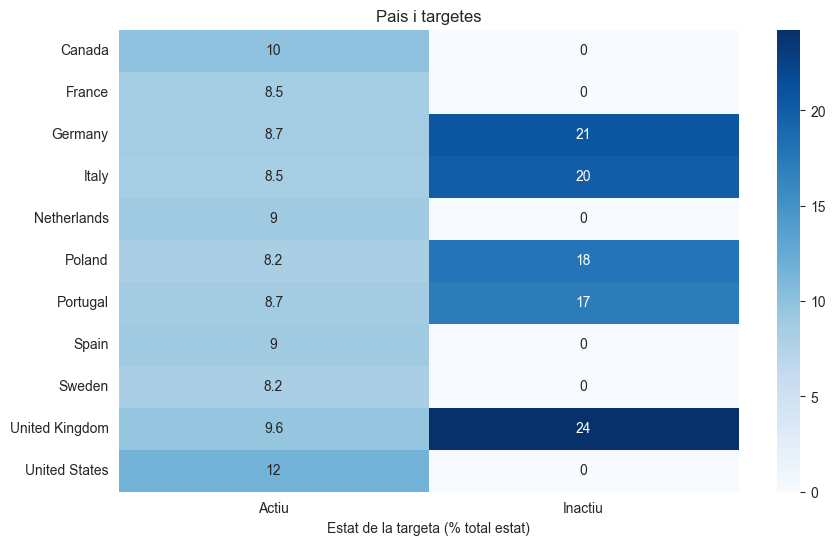

In [29]:
ct = pd.crosstab(
    df_users_transactions_active['country'],
    df_users_transactions_active['state'],
    normalize = "columns"
) * 100

plt.figure(figsize=(10,6))
ax = sns.heatmap(ct, annot=True, cmap='Blues')

ax.set_xticklabels(['Actiu', 'Inactiu'])

plt.title('Pais i targetes')
plt.xlabel('Estat de la targeta (% total estat)')
plt.ylabel('')
plt.show()

**Interpretació dels resultats**

En general, hi ha poques targetes inactives, amb alguns països on no n'hi ha cap. Pel que fa a les targetes actives, Estats Units i Canada són els que tenen més percentatge de targetes actives, mentre que a Europa el nombre és més igualat.

Altra opció de gràfic  
ct_norm = pd.crosstab(
    df_users_transactions_active['country'],
    df_users_transactions_active['state'],
    normalize='index'
)*100

ax = ct_norm.plot(kind='bar', stacked=True, figsize=(10,6))

ax.set_ylim(0, 120)  # o 120 si has multiplicat per 100

#### Tres variables combinades.

Preparació de les dades

In [30]:
df_users.head(2)

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,america
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,"Apr 30, 1984",United States,San Jose,95101,P.O. Box 773,america


In [31]:
df_users_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_user           100000 non-null  str           
 1   name              100000 non-null  str           
 2   surname           100000 non-null  str           
 3   phone             100000 non-null  str           
 4   email             100000 non-null  str           
 5   birth_date        100000 non-null  str           
 6   country           100000 non-null  str           
 7   city              100000 non-null  str           
 8   postal_code       100000 non-null  str           
 9   address           100000 non-null  str           
 10  region            100000 non-null  str           
 11  id_trans          100000 non-null  str           
 12  card_id           100000 non-null  str           
 13  business_id       100000 non-null  str           
 14  transaction_date

In [32]:
df_users_transactions['birth_date'] = pd.to_datetime(df_users_transactions['birth_date'],format='mixed')
df_users_transactions['birth_date'].info()

<class 'pandas.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: birth_date
Non-Null Count   Dtype         
--------------   -----         
100000 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 781.4 KB


In [33]:
def calcul_edat(data_naixement: datetime, data_compra:datetime) -> int:
    """
    Calcula l'edat al moment de la compra a partir de la data de naixement.

    L'edat es calcula tenint en compte si l'aniversari d'aquest any
    ja ha passat o no.

    Args:
        data_naixement (datetime): Data de naixement de la persona.
        data_compra (datetime): Data de compra de la persona.

    Returns:
        int: Edat en anys respecte la compra realitzada.
    """
    edat_actual = data_compra.year - data_naixement.year - ((data_compra.month, data_compra.day) < (data_naixement.month, data_naixement.day))
    # Comparació de tuples: primer compara mesos i si són iguals compara dies. El resultat és True (1) o False(0). SI no ha passat l'aniversari, resta un any.

    return edat_actual

In [34]:
df_users_transactions['edat_compra'] = df_users_transactions.apply(
    lambda row: calcul_edat(row['birth_date'], row['transaction_date']),
    axis=1
)

In [35]:
df_users_transactions.head(2)

,id_user,name,surname,phone,email,birth_date,country,city,postal_code,address,...,card_id,business_id,transaction_date,amount,declined,product_ids,user_id,lat,longitude,edat_compra
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,CcU-4856,b-2314,2022-01-25 22:57:15,272.45,0,"81, 94, 95, 66, 64",1,40.71746049737034,-73.9960221869998,36
1,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,CcU-4856,b-2494,2016-09-22 02:43:55,212.74,0,"58, 47",1,40.72221709395199,-73.99851142917672,30


In [36]:
df_users_transactions['age_group'] = pd.cut(
    df_users_transactions['edat_compra'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '30-45', '45-60', '60+']
)

df_users_transactions

,id_user,name,surname,phone,email,birth_date,country,city,postal_code,address,...,business_id,transaction_date,amount,declined,product_ids,user_id,lat,longitude,edat_compra,age_group
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,b-2314,2022-01-25 22:57:15,272.45,0,"81, 94, 95, 66, 64",1,40.71746049737034,-73.9960221869998,36,30-45
1,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,b-2494,2016-09-22 02:43:55,212.74,0,"58, 47",1,40.72221709395199,-73.99851142917672,30,18-30
2,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,b-2426,2024-11-15 14:48:20,254.46,0,"94, 96, 12",1,40.70699307188861,-74.00549615970634,38,30-45
3,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,b-2446,2018-11-03 03:57:13,479.39,0,"59, 12, 88, 81",1,40.71253477256239,-73.9978629697294,32,30-45
4,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,...,b-2294,2019-12-04 20:36:55,384.75,0,"4, 57, 2, 79",1,40.71772180324366,-74.01015688500497,34,30-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,999,Jxnziq,Swketlik,+70-735-4881,jxnziq.swketlik@example.com,1995-01-26,Portugal,Lisbon,1000-001,513 Swketlik St,...,b-2306,2020-01-29 18:22:39,445.29,0,"44, 9, 88, 87",999,38.7171036292868,-9.145243480596024,25,18-30
99996,999,Jxnziq,Swketlik,+70-735-4881,jxnziq.swketlik@example.com,1995-01-26,Portugal,Lisbon,1000-001,513 Swketlik St,...,b-2618,2022-10-15 17:25:06,400.85,0,"13, 11, 100, 3",999,38.72294018848261,-9.14087459835299,27,18-30
99997,999,Jxnziq,Swketlik,+70-735-4881,jxnziq.swketlik@example.com,1995-01-26,Portugal,Lisbon,1000-001,513 Swketlik St,...,b-2466,2015-10-08 09:48:19,247.4,0,"21, 77",999,38.714795913839126,-9.139423027944256,20,18-30
99998,999,Jxnziq,Swketlik,+70-735-4881,jxnziq.swketlik@example.com,1995-01-26,Portugal,Lisbon,1000-001,513 Swketlik St,...,b-2542,2019-04-03 22:59:38,151.78,0,99,999,38.72604874676719,-9.140709052868498,24,18-30


In [37]:
df_users_transactions['amount'] = pd.to_numeric(
    df_users_transactions['amount'],
    errors='coerce'
)

Gràfica

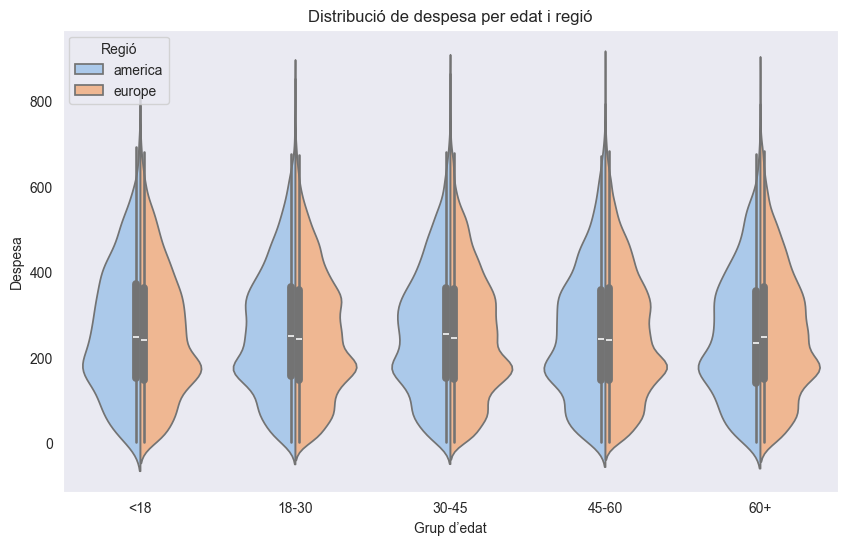

In [38]:
plt.figure(figsize=(10,6))

ax = sns.violinplot(
    data=df_users_transactions,
    x='age_group',
    y='amount',
    hue='region',
    inner='box',
    split=True
)

ax.yaxis.set_major_locator(ticker.MaxNLocator(6)) 

plt.title('Distribució de despesa per edat i regió')
plt.xlabel('Grup d’edat')
plt.ylabel('Despesa')
plt.legend(title='Regió')
plt.show()

**Interpretació dels resultats**

Pel que fa a la despesa entre regions del mateix grup d'edat, no s'observen grans diferències en la distribució general. Valors mínims, màxims i mediana són semblants dintre de cada grup per a les regions d'Amèrica i Europa.
També s'observa que en tots els grups d'edat hi ha més transaccions del voltant de 200, així com en tots els grups menys als de menors de 18 anys veiem que també hi ha un nombre més elevat de transaccions de gairebé 400 dòlars.

Altra manera de fer-ho:  
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_users_transaction_2_country, x='edat_compra', y= 'amount', hue='region')

plt.title('Despesa per edat i regió')
plt.xlabel('Despesa mitjana per compra')
plt.ylabel('Edat mitjana usuari')
plt.show()

Plotly express mapa  
fig = px.scatter_geo(
    df_users_transactions,
    lat='lat',
    lon='longitude',
    color='amount',
    color_continuous_scale='Reds',
    #hover_name='user_country',
    title='Despesa mitjana per país'
)

fig.show()

👉 Quan amount és object (string), Seaborn:

no el tracta com a variable numèrica real
pot ordenar malament
o construir el violin de forma estranya

Amb això:

df_users_transactions['amount'] = pd.to_numeric(
    df_users_transactions['amount'],
    errors='coerce'
)

✔️ ja forces comportament correcte
✔️ coincideix amb Power BI
✔️ el violinplot és coherent

💡 Insight important (per futurs errors)
Si un gràfic “sembla raro”:
👉 comprova sempre:

df.dtypes

Si veus:

amount    object

🚨 sospitós

#### Crea un Pairplot.

Preparació dades

In [39]:
df_pairplot = pd.merge(df_count_products_price[['product','units_sold','price']],df_products[['id','weight']], left_on='product',right_on='id')
df_pairplot = df_pairplot.drop(columns=['id'])
df_plot = df_pairplot[['units_sold', 'price', 'weight']].rename(columns={
    'units_sold': 'Unitats Venudes',
    'price': 'Preu',
    'weight': 'Pes'
})

df_plot

,Unitats Venudes,Preu,Pes
0,2602,180.91,3
1,2532,53.01,2
2,2520,65.25,1
3,2591,96.26,1.5
4,2590,2.12,0.8
...,...,...,...
95,2479,114.77,2.7
96,2502,68.38,2.1
97,2453,150.50,3.2
98,2514,189.21,2


In [40]:
df_plot['Pes'] = df_plot['Pes'].astype(float)

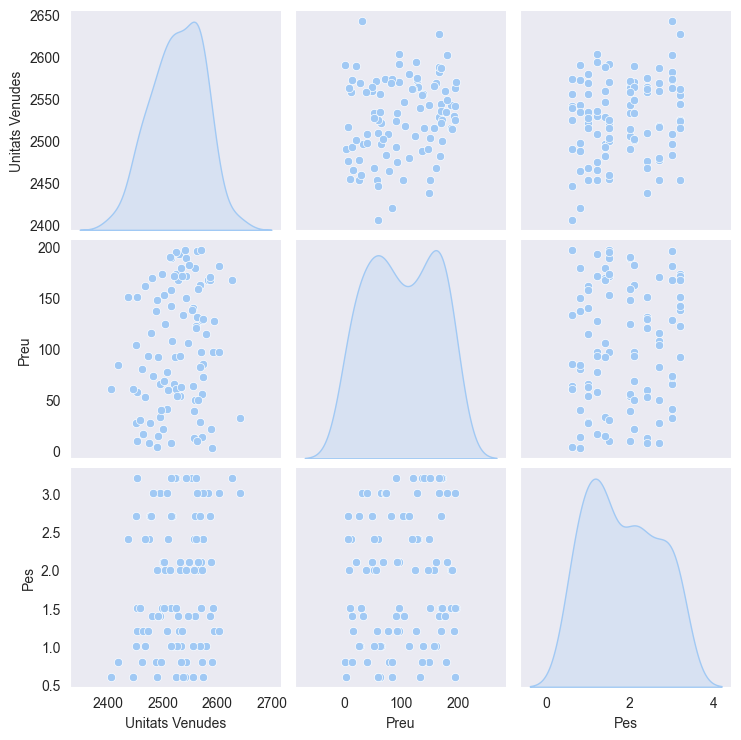

In [41]:
sns.pairplot(df_plot[['Unitats Venudes', 'Preu', 'Pes']], diag_kind='kde')

plt.show()

**Interpretació dels resultats**

En les tres variables estudiades no es veu cap patró concret de relació entre elles. No obstant, en els gràfics de dispersió on hi ha el pes involucrat veiem que es diferencien dos grups i que no hi ha produces entre aproximadament 1,5 i 2 de pes.
Pel que fa a la distribució de les variables, les unitats venudes segueixen una distribució normal, sent el valor més comú entre 2500 i 2600. Pel que fa al preu i al pes no segueixen una distribució normal, observant que hi ha dos rangs de preus que són més comuns, mentre que són més comuns els productes amb un pes relativament baix.

### Tancar cursor i connexió amb MySQL

In [42]:
cursor.close()
connection.close()

if not connection.is_connected():
    print("Connexió tancada correctament ✅")

Connexió tancada correctament ✅


In [43]:
try:
    cursor.execute("SELECT 1")
except:
    print("Cursor tancat o connexió no disponible ✅")

Cursor tancat o connexió no disponible ✅


## **Nivell 2**

### **1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.**

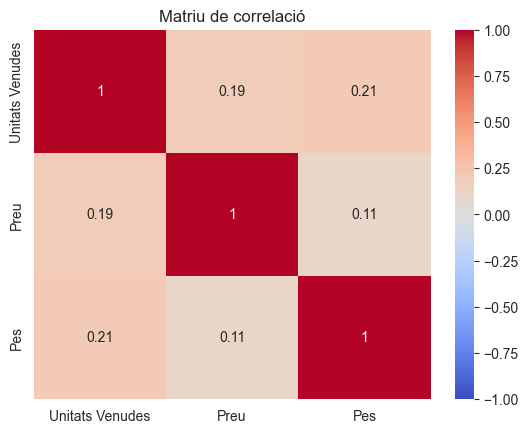

In [44]:
corr = df_plot[['Unitats Venudes', 'Preu', 'Pes']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Matriu de correlació")
plt.show()

**Interpretació dels resultats**

Segons la matriu de correlació, exsteix una relació positiva fluixa entre les variables estudiades, o sigui que en quan una de les variables augmenta també ho fa l'altra.

### **2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.**

In [45]:
df_count_products_price.head()

,product,units_sold,price
0,16,2602,180.91
1,26,2532,53.01
2,97,2520,65.25
3,87,2591,96.26
4,66,2590,2.12


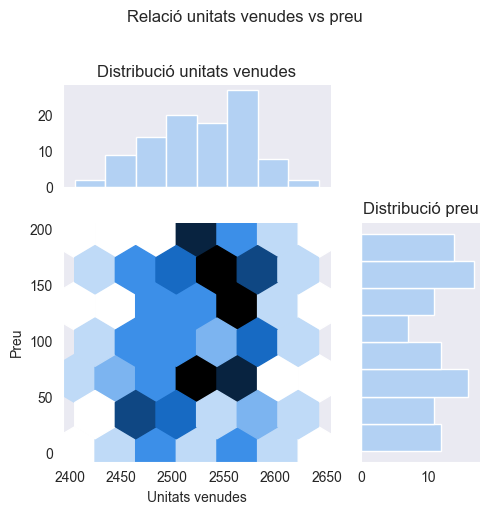

In [46]:
fig = sns.jointplot(data=df_count_products_price, x="units_sold", y="price", kind="hex", height=5, ratio=2, marginal_ticks=True)
fig.set_axis_labels("Unitats venudes", "Preu")
fig.ax_marg_x.set_title("Distribució unitats venudes")
fig.ax_marg_y.set_title("Distribució preu")
plt.suptitle("Relació unitats venudes vs preu", y=1.02)
plt.tight_layout()
plt.show()

**Interpretació dels resultats**

Pel que fa a les distribucions de les unitats venudes i de preu, la d'unitats venudes segueix una distribució nrmal on és més comú vendre 2550 unitats aproximadament. Mentre que pel preu hi ha dos preus que són semblants pel que fa a com de comú són (aproximadament 175 i 60).
Per veure la correlació entre ambdues, predominen els productes on s'han venut entre 2500 i 2600 aproximadament, amb els mateios grups diferenciats que s'oberven a la distribució.

## **Nivell 3**

### **1. Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.**

Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.

En les cel·les següents es recull el codi emprat a Power BI per a la càrrega de dades i la creació de les visualitzacions.

El resultat complet es pot visualitzar en el fitxer *.pbix* ubicat a la mateixa carpeta del projecte.

Codi script Python. Actualitzar **contrasenya** al posar-ho a PowerBI.

In [ ]:
import mysql.connector
from mysql.connector import Error
import pandas as pd


try:
    connection = mysql.connector.connect(host='localhost',
                                         database='s4_transactions',
                                         user='root',
                                       #  password='MySQL password') need to put password!
    if connection.is_connected():
        cursor = connection.cursor(buffered=True)
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)


cursor.execute("Show tables;")

tables = cursor.fetchall()

def select_table(table_name: str):
    # table_name = table_name[0] retorna una tuple el fetch all de noms de les taules
    query = f"SELECT * FROM {table_name}"
    cursor.execute(query)
    
    data = cursor.fetchall()
    columns = [col[0] for col in cursor.description]

    df = pd.DataFrame(data, columns=columns)
    return df

tables_df = {}

for x in tables:
    table_name = x[0]
    tables_df[table_name] = select_table(table_name)

# aquí definir cadascuna de les variables

df_active_credit_cards = tables_df['active_credit_cards']
df_companies = tables_df['companies']
df_users = tables_df['all_users']
df_credit_cards = tables_df['credit_cards']
df_products = tables_df['products']
df_transaction_product = tables_df['transaction_product']
df_transactions = tables_df['transactions']


query = """
SELECT p.id AS product, COUNT(p.id) as units_sold, p.price
FROM products p
JOIN transaction_product tp ON tp.product_id = p.id
JOIN transactions t ON tp.transaction_id = t.id
WHERE declined = 0
GROUP BY p.id
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = [col[0] for col in cursor.description]

df_count_products_price = pd.DataFrame(data, columns=columns)


query = """
SELECT t.id, t.amount, u.country
FROM transactions t
JOIN all_users u ON u.id = t.user_id
WHERE declined = 0
"""

cursor.execute(query)

data = cursor.fetchall()  
columns = [col[0] for col in cursor.description]

df_transaction_country = pd.DataFrame(data, columns=columns)

#### Una variable numèrica.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("dark")
sns.set_palette("pastel")

# neteja de la columna price
dataset['price'] = dataset['price'].str.replace('$', '', regex=False)
dataset['price'] = pd.to_numeric(dataset['price'], errors='coerce')

# gràfic
sns.histplot(data=dataset, x='price')
plt.title('Product price distribution')
plt.show()

#### Dues variables numèriques.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("dark")
sns.set_palette("pastel")

# neteja de la columna price
dataset['price'] = dataset['price'].str.replace('$', '', regex=False)
dataset['price'] = pd.to_numeric(dataset['price'], errors='coerce')

sns.scatterplot(data=dataset, x='units_sold', y= 'price').set(title='Preu producte i Ventes',xlabel='Unitats venudes', ylabel='Preu')
plt.show()

#### Una variable categòrica.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")
sns.set_palette("pastel")

dataset['amount'] = dataset['amount'].astype(float)
order = dataset.groupby('country')['amount'].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=dataset,
    x='country',
    y='amount',
    order=order,
    inner='box',
    palette='husl' # Fa que cadascun dels violinplots sigui d'un color
)

plt.title('Distribució de despesa per ticket per país')
plt.xlabel('País')
plt.ylabel('Despesa ($)')
plt.xticks(rotation=45)
plt.show()

#### Una variable categòrica i una numèrica.

In [ ]:
# Fet amb seaborn aquest cop, mirar següent cel·la per explicació
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



dataset['amount'] = dataset['amount'].astype(float)
order = dataset.groupby('country')['amount'].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=dataset,
    x='country',
    y='amount',
    order=order,
    inner='box'
)

plt.title('Distribució de despesa per ticket per país')
plt.xlabel('País')
plt.ylabel('Despesa ($)')
plt.xticks(rotation=45)
plt.show()

El següent codi no crea la imatge a PowerBI, obre una pàgina web amb la figura. Segons chatGPT:

Això passa perquè Power BI Python Visual no renderitza figures interactives de Plotly dins del visual.  
fig.show() amb Plotly sovint obre el navegador o una finestra externa, però no pinta res al canvas de Power BI.

*El motiu*  
En un Python visual de Power BI, el que es renderitza bé és sobretot una imatge estàtica, normalment amb matplotlib (i seaborn, que al final també dibuixa amb matplotlib).

plotly.express crea una figura HTML/JS interactiva, i Power BI no la incrusta dins del Python visual.

*Conclusió*  
Aquest codi amb Plotly pot funcionar fora de Power BI, però dins Power BI no et servirà per veure el gràfic al visual.

**_Solució_**
Has de fer aquest violinplot amb seaborn o matplotlib.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


dataset['amount'] = dataset['amount'].astype(float)
order = dataset.groupby('country')['amount'].median().sort_values().index

fig = px.violin(
    dataset,
    x='country',
    y='amount',
    color='country',
    box=True,
    points='outliers',
    category_orders={'country': order},
    title='Distribució de despesa per ticket per país',
    labels={
        'country': 'País',
        'amount': 'Despesa ($)'
    }
)


fig.update_yaxes(tickformat=",")
fig.update_layout(
    showlegend=False,
    xaxis_tickangle=45
)

fig.show()

#### Dues variables categòriques.

In [ ]:
# Primer he hagut de crear les relacions entre el model de dades i després posat els paràmetres que volia al nouy dataset per a la gràfica

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")
sns.set_palette("pastel")

ct = pd.crosstab(
    dataset['country'],
    dataset['state'],
    normalize = "columns"
) * 100

plt.figure(figsize=(10,6))
ax = sns.heatmap(ct, annot=True, cmap='Blues')

ax.set_xticklabels(['Actiu', 'Inactiu'])

plt.title('Pais i targetes')
plt.xlabel('Estat de la targeta (% total estat)')
plt.ylabel('')
plt.show()

#### Tres variables combinades.

Per a calcular l'edat de compra, he creat al model una nova columna amb DAX:  
Edat_Compra = 
YEAR(df_transactions[transaction_date]) - YEAR(RELATED(df_users[birth_date])) -
IF(
    MONTH(df_transactions[transaction_date]) < MONTH(RELATED(df_users[birth_date])) ||
    (
        MONTH(df_transactions[transaction_date]) = MONTH(RELATED(df_users[birth_date])) &&
        DAY(df_transactions[transaction_date]) < DAY(RELATED(df_users[birth_date]))
    ),
    1,
    0
)

In [ ]:
# Amb seaborn, no renderitza PowerBI plotly express, la llegenda s'ha de posr amb ax, quedava al mig i la volia moure

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")
sns.set_palette("pastel")

order = (
    dataset[['Age_Group', 'Age_Group_Order']]
    .drop_duplicates()
    .sort_values('Age_Group_Order')['Age_Group']
)

plt.figure(figsize=(10,6))

ax = sns.violinplot(
    data=dataset,
    x='Age_Group',
    y='amount',
    hue='region',
    inner='box',
    split=True,
    order=order
)

# llegenda controlada des de ax
legend = ax.legend(
    loc='upper left',
    framealpha=0.6,
    title='Regió'
)

plt.title('Distribució de despesa per edat i regió')
plt.xlabel('Grup d’edat')
plt.ylabel('Despesa')
plt.tight_layout()

plt.show()

#### Crea un Pairplot.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("dark")
sns.set_palette("pastel")

sns.pairplot(dataset[['units_sold', 'price', 'weight']], diag_kind='kde')
plt.show()

### Pàgines web

- [How to Show All Tables in MySQL using Python?](https://www.geeksforgeeks.org/python/how-to-show-all-tables-in-mysql-using-python/)
- [From data to viz](https://www.data-to-viz.com/)
- [Comprehensive Guide to Adding Titles and Customizing Seaborn Boxplots](https://www.geeksforgeeks.org/data-visualization/comprehensive-guide-to-adding-titles-and-customizing-seaborn-boxplots/)
- [How To Set Title On Seaborn Jointplot? - Python](https://www.geeksforgeeks.org/data-visualization/how-to-set-title-on-seaborn-jointplot-python/)